## Logistic Regession And Decision Tree

In [69]:
'''1. Read the dataset and seperate the input and output columns 2. Plot
the graph of class balancing
3. Perform train-test split with 80% and 20%
4. Create logistic regression model
5. Find accuracy, confusion matrix and classification report 6.
Perform the prediction of single value entry.
''';

In [70]:
import pandas as pd
import zipfile

zip = zipfile.ZipFile("seeds.zip")
zip.extractall()
zip.close()




In [71]:
df = pd.read_csv("seeds_dataset.txt", sep="\s+", header=None)
df.columns = ["area", "perimeter", "compactness", "length", "width", "asymmetry", "groove", "type"]



In [72]:
x = df.drop(['type'],axis=1)
y = df["type"]


In [73]:
df.head()

,area,perimeter,compactness,length,width,asymmetry,groove,type
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [74]:
df.shape

(210, 8)

In [75]:
x.shape

(210, 7)

In [76]:
y.shape

(210,)

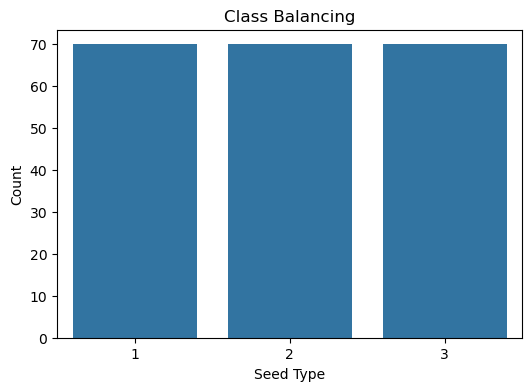

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Balancing")
plt.xlabel("Seed Type")
plt.ylabel("Count")
plt.show()

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(168, 7)
(42, 7)
(168,)
(42,)


In [80]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

In [81]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay,classification_report,confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9047619047619048
Classification Report:
               precision    recall  f1-score   support

           1       0.82      0.82      0.82        11
           2       1.00      1.00      1.00        14
           3       0.88      0.88      0.88        17

    accuracy                           0.90        42
   macro avg       0.90      0.90      0.90        42
weighted avg       0.90      0.90      0.90        42



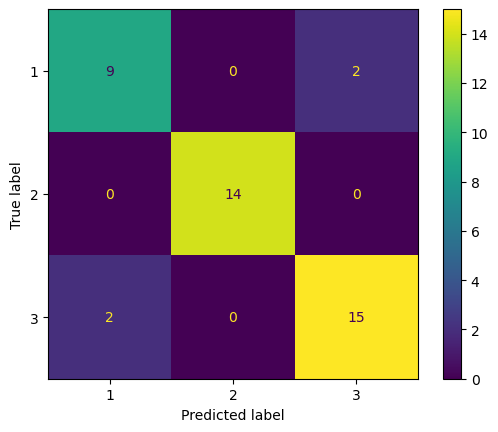

In [82]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred);

In [83]:
import joblib
joblib.dump(model, "logistic_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']